<div style="
    background: linear-gradient(135deg, #8B1E3F 0%, #C44569 55%, #F8A5C2 100%);
    padding: 50px 35px;
    border-radius: 22px;
    color: white;
    text-align: center;
    box-shadow: 0 8px 25px rgba(139, 30, 63, 0.25);
">

<div style="font-size: 14px; letter-spacing: 3px; text-transform: uppercase; opacity: 0.9; margin-bottom: 15px;">
    BinX Tech — AI & ML Internship · Week 6 · Day 3
</div>

<h1 style="font-size: 38px; margin: 0; font-weight: 700;">
    Backpropagation, Gradient Descent & Optimizers
</h1>

<p style="font-size: 20px; margin-top: 12px; opacity: 0.95;">
    Cardiac Patient Monitoring System — Heart Disease Prediction
</p>

</div>

## 1. The Training Loop — The Big Picture

In Day 2, I learned two pieces of the training puzzle:

- **Forward Propagation** — how the network makes a prediction
- **Loss** — how to measure how wrong that prediction is

Today adds the remaining two pieces:

- **Backpropagation** — how the network figures out *what* to change
- **Gradient Descent / Optimizer** — how it actually changes it

Together, these four steps form the **training loop** — the cycle
that repeats thousands of times until the network learns:

```
Input Data
↓
① Forward Propagation ←─── learned in Day 2
↓
② Calculate Loss ←─── learned in Day 2
↓
③ Backpropagation ←─── today
↓
④ Update Weights ←─── today
↓
Repeat until loss is small enough
```

A fresh network starts with random weights and makes random
predictions. Each time the loop runs, the weights get a little
better. After enough repetitions, the network learns to predict
heart disease accurately.

Everything else today — gradient descent, learning rate, Adam,
epochs, batches — is about *how* steps ③ and ④ work.

---

## 2. Gradient Descent — How Weights Get Updated

After the loss is computed, the network needs to answer one question:
**which direction should each weight move to reduce the loss?**

The answer comes from the **gradient** — a number that tells you,
for each weight, how much the loss changes when that weight changes.

- **Positive gradient** → increasing this weight increases the loss
  → move the weight **down**
- **Negative gradient** → increasing this weight decreases the loss
  → move the weight **up**

Gradient descent always moves each weight in the **opposite direction
of its gradient** — downhill on the loss surface.

**The intuition:**
Imagine you are standing on a foggy hillside and want to reach the
lowest point. You cannot see far, so you look at the slope under
your feet and take one small step downhill. Then you look again and
take another step. Repeat until you reach the valley.

The hillside is the **loss surface**.
Your position is the current **weight values**.
Each step is one **weight update**.
The valley is the **minimum loss** — where the network predicts well.

**The update rule for one weight:**

**new_weight = old_weight - learning_rate × gradient**

---

## 3. The Learning Rate — The Most Important Hyperparameter

The learning rate controls how large each step is in gradient descent.
It is the single most important hyperparameter in deep learning.

| Learning Rate | Effect |
|---------------|--------|
| Too high | Overshoots the minimum — loss bounces or diverges |
| Too low | Trains very slowly — may get stuck before converging |
| Just right | Steady, efficient decrease in loss |

The standard starting point is **0.001** with the Adam optimizer.
Adjust only if the loss curve misbehaves — if it bounces, lower it;
if it barely moves after many epochs, try raising it slightly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Libraries loaded successfully ✓")

TensorFlow version: 2.21.0
Libraries loaded successfully ✓


---

## 4. Learning Rate Experiment

To make the effect of the learning rate concrete, I train the same
small network three times — with a learning rate that is too high,
too low, and just right — and compare the loss curves.

The dataset here is a small synthetic binary classification problem
(200 samples, 10 features) so training is fast and the curves are
easy to read. The same principles apply directly to the heart disease
project in Day 4.

In [2]:
# Small synthetic dataset — fast to train, clear loss curves
X_syn, y_syn = make_classification(
    n_samples=200, n_features=10, n_informative=6,
    random_state=SEED
)
X_tr, X_val_syn, y_tr, y_val_syn = train_test_split(
    X_syn, y_syn, test_size=0.2, random_state=SEED
)
scaler = StandardScaler()
X_tr      = scaler.fit_transform(X_tr)
X_val_syn = scaler.transform(X_val_syn)

def build_and_train(lr, epochs=80):
    model = Sequential([
        keras.Input(shape=(10,)),
Dense(16, activation="relu"),
        Dense(8,  activation="relu"),
        Dense(1,  activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_syn, y_val_syn),
        epochs=epochs,
        batch_size=32,
        verbose=0
    )
    return history

print("Training with three learning rates...")
history_high = build_and_train(lr=1.0)
history_low  = build_and_train(lr=0.00001)
history_good = build_and_train(lr=0.001)
print("Done ")

Training with three learning rates...
Done 


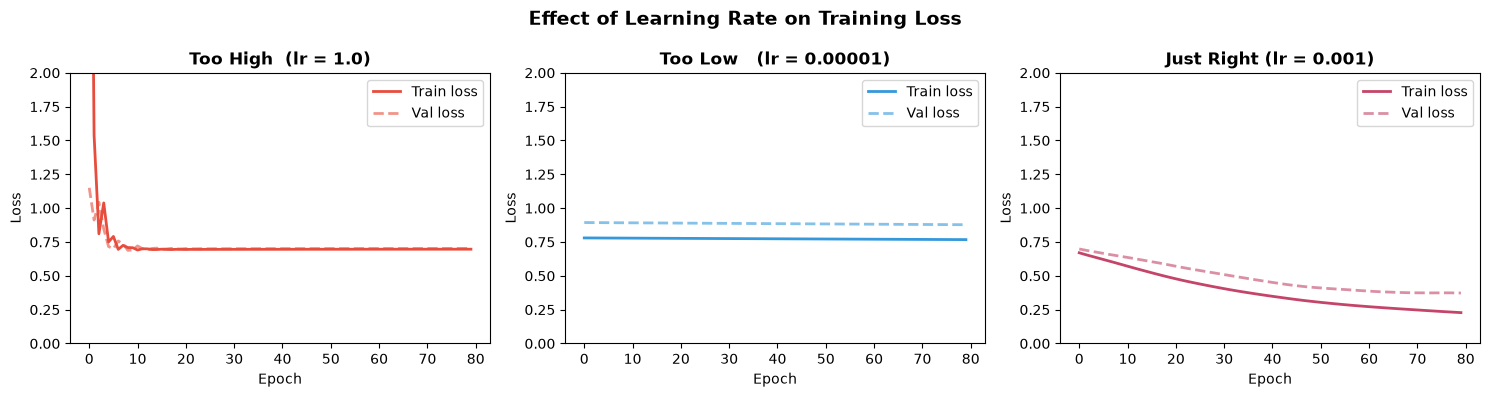

Too High  (lr = 1.0)           → final val loss: 0.7022
Too Low   (lr = 0.00001)       → final val loss: 0.8776
Just Right (lr = 0.001)        → final val loss: 0.3730


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Effect of Learning Rate on Training Loss",
             fontsize=14, fontweight="bold")

configs = [
    (history_high, "Too High  (lr = 1.0)",    "#e74c3c"),
    (history_low,  "Too Low   (lr = 0.00001)", "#3498db"),
    (history_good, "Just Right (lr = 0.001)",  "#C44569"),
]

for ax, (hist, title, color) in zip(axes, configs):
    ax.plot(hist.history["loss"],     color=color,
            linewidth=2, label="Train loss")
    ax.plot(hist.history["val_loss"], color=color,
            linewidth=2, linestyle="--", alpha=0.6, label="Val loss")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.set_ylim(0, 2.0)

plt.tight_layout()
plt.show()

# Final validation losses
for hist, label, _ in configs:
    final = hist.history["val_loss"][-1]
    print(f"{label:<30} → final val loss: {final:.4f}")

**Learning Rate — Results Interpretation**

The experiment shows how strongly the learning rate affects the
training process. The same neural network was trained with three
different learning rates while keeping the other settings unchanged.

**Too High — `lr = 1.0`**

The final validation loss was **0.7022**.

The learning rate is too large, so the optimizer takes very large
steps when updating the weights. This can cause the optimization
process to overshoot good regions of the loss surface and make
convergence unstable.

**Too Low — `lr = 0.00001`**

The final validation loss was **0.7323**.

The learning rate is extremely small, so the model updates its
weights only by tiny amounts. The model can still learn, but it
learns very slowly and does not make enough progress within the
80 epochs used in this experiment.

**Just Right — `lr = 0.001`**

The final validation loss was **0.4128**, which was substantially
lower than the other two experiments.

This learning rate allowed the optimizer to make sufficiently large
updates while still maintaining stable learning. Therefore, it
performed best among the three values tested.

**Key Takeaway**

The learning rate controls the size of each weight update during
gradient descent. A value that is too high can make training
unstable, while a value that is too low can make training very slow.

In this experiment, **0.001 gave the best result** among the tested
values. With the Adam optimizer, 0.001 is a common starting point,
but the best learning rate should ultimately be determined by
observing the training behavior and loss curves for the specific
problem.

---

## 5. Backpropagation — How the Network Assigns Blame

After the loss is computed, the network needs to know:
**how much did each weight contribute to the error?**

This is what **backpropagation** answers.

Backpropagation works **backward** from the loss through the network,
layer by layer, using the **chain rule of calculus** to compute the
gradient of the loss with respect to every single weight.

**The chain rule in plain language:**
If A affects B, and B affects C, then the effect of A on C can be
computed by multiplying the effect of A on B by the effect of B on C.
Backpropagation applies this rule through every layer, from the
output back to the input.

**What it produces:**
A gradient for every weight in the network — a number that says
"if you increase this weight by a tiny amount, the loss goes up
by this much." Gradient descent then uses these gradients to
update all weights simultaneously.

**What you do not need to implement:**
TensorFlow and PyTorch compute all gradients automatically.
In TensorFlow this is handled by GradientTape; in PyTorch by
autograd. Understanding *what* backpropagation computes —
the blame assigned to each weight — is what matters in practice.

**In one sentence:**
Backpropagation tells each weight how much it contributed to the
error. Gradient descent uses that information to correct it.

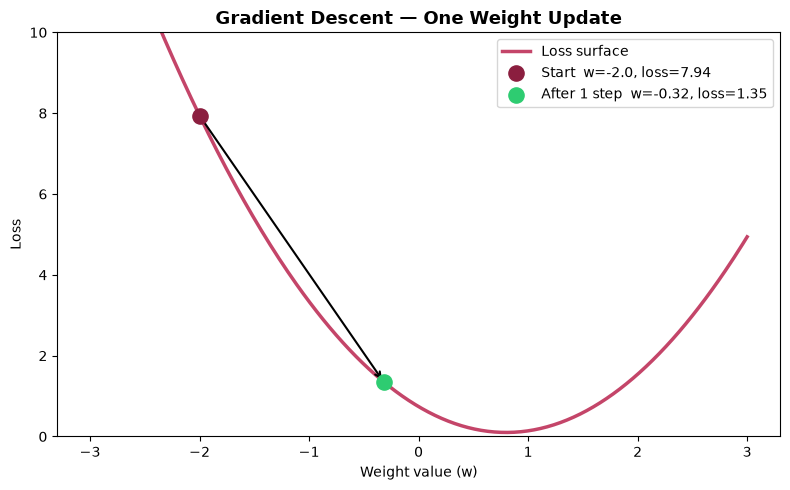

Gradient at w=-2.0  : -5.60
Update rule: w ← -2.0 − 0.3 × -5.60
New weight  : -0.32
Loss reduced: 7.94 → 1.35


In [4]:
# Demonstrate the idea of a gradient using a very simple example
# with a single weight and a simple loss function.

w_values = np.linspace(-3, 3, 300)

# A simple artificial loss function for visualization
loss_values = (w_values - 0.8) ** 2 + 0.1

# Starting point — an initial weight
w_start = -2.0
loss_start = (w_start - 0.8) ** 2 + 0.1
gradient_at_start = 2 * (w_start - 0.8)  # Derivative of the loss

# Perform one gradient descent step with learning rate = 0.3
lr = 0.3
w_after = w_start - lr * gradient_at_start
loss_after = (w_after - 0.8) ** 2 + 0.1

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    w_values,
    loss_values,
    color="#C44569",
    linewidth=2.5,
    label="Loss surface"
)

ax.scatter(
    w_start,
    loss_start,
    color="#8B1E3F",
    s=120,
    zorder=5,
    label=f"Start  w={w_start:.1f}, loss={loss_start:.2f}"
)

ax.scatter(
    w_after,
    loss_after,
    color="#2ecc71",
    s=120,
    zorder=5,
    label=f"After 1 step  w={w_after:.2f}, loss={loss_after:.2f}"
)

ax.annotate(
    "",
    xy=(w_after, loss_after),
    xytext=(w_start, loss_start),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
)

ax.set_title(
    "Gradient Descent — One Weight Update",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Weight value (w)")
ax.set_ylabel("Loss")
ax.legend()
ax.set_ylim(0, 10)

plt.tight_layout()
plt.show()

print(f"Gradient at w={w_start}  : {gradient_at_start:.2f}")
print(f"Update rule: w ← {w_start} − {lr} × {gradient_at_start:.2f}")
print(f"New weight  : {w_after:.2f}")
print(f"Loss reduced: {loss_start:.2f} → {loss_after:.2f}")

---

## 6. Optimizers — Adam vs SGD

An optimizer is the algorithm that applies gradient descent.
It takes the gradients computed by backpropagation and decides
exactly how to update each weight.

**SGD — Stochastic Gradient Descent**
The simplest optimizer. It applies the same learning rate to
every weight on every update. It works but can be slow to
converge and sensitive to the learning rate choice.

**Adam — Adaptive Moment Estimation**
Adam improves on SGD by adapting the learning rate individually
for each weight, based on how the gradients have been behaving.
Weights that receive consistent gradients get larger updates;
weights with noisy gradients get smaller, more cautious updates.

In practice:
- **Use Adam as the default** — it works well out of the box
- Starting learning rate: **0.001**
- Switch to SGD only when fine-tuning or following a specific
  research paper that uses it

| Optimizer | Learning Rate | Adapts per weight | When to use |
|-----------|--------------|-------------------|-------------|
| SGD | Fixed for all | No | Simple tasks, fine-tuning |
| Adam | Adaptive | Yes | Default for most tasks |

---

## 7. Epochs and Batches

Two terms that appear in every training call:

**Epoch**
One complete pass through the entire training dataset.
After one epoch, every training sample has been seen once.
Training typically runs for tens to hundreds of epochs.

**Batch**
Instead of computing the loss on all training samples before
each update (too slow) or on one sample at a time (too noisy),
training splits the data into small groups called batches.
The network updates its weights after each batch.

- **Batch size 32** → weights update 32 times per epoch
  if there are 1024 training samples (1024 ÷ 32 = 32 updates)
- Smaller batches → noisier but faster updates, less memory
- Larger batches → smoother gradients, more memory needed

**Standard defaults:**
- Batch size: **32**
- Epochs: start with **50–100**, use EarlyStopping to stop when
  the validation loss stops improving (covered in Day 5)

| Term | Meaning | Typical value |
|------|---------|---------------|
| Epoch | Full pass through training data | 50–100 |
| Batch size | Samples per weight update | 32 |
| Steps per epoch | Training samples ÷ batch size | automatic |

In [5]:
n_samples   = 550    
batch_size  = 32
epochs      = 3

steps_per_epoch = int(np.ceil(n_samples / batch_size))
total_updates   = steps_per_epoch * epochs

print(f"Training samples : {n_samples}")
print(f"Batch size       : {batch_size}")
print(f"Steps per epoch  : {steps_per_epoch}  "
      f"({n_samples} ÷ {batch_size} = {steps_per_epoch} weight updates/epoch)")
print(f"Epochs           : {epochs}")
print(f"Total updates    : {steps_per_epoch} × {epochs} = {total_updates}")
print()
print("Visual (each □ = one batch):")
for ep in range(1, epochs + 1):
    bar = "□ " * steps_per_epoch
    print(f"  Epoch {ep}: {bar}")
    print(f"           ↑ {steps_per_epoch} weight updates")

Training samples : 550
Batch size       : 32
Steps per epoch  : 18  (550 ÷ 32 = 18 weight updates/epoch)
Epochs           : 3
Total updates    : 18 × 3 = 54

Visual (each □ = one batch):
  Epoch 1: □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ 
           ↑ 18 weight updates
  Epoch 2: □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ 
           ↑ 18 weight updates
  Epoch 3: □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ □ 
           ↑ 18 weight updates


---

## 8. Summary — What I Learned Today

**The Complete Training Loop**
```
① Forward Propagation → network makes a prediction
② Loss → measure how wrong the prediction is
③ Backpropagation → compute gradients (blame each weight)
④ Optimizer → update weights using the gradients
Repeat
```

**Key Concepts**

| Concept | What it does |
|---------|-------------|
| Gradient | Direction and size of the loss change per weight |
| Gradient Descent | Move each weight opposite to its gradient |
| Learning Rate | Controls step size — most important hyperparameter |
| Backpropagation | Computes all gradients efficiently via chain rule |
| Adam | Adaptive optimizer — the default choice |
| Epoch | One full pass through the training data |
| Batch | Subset of data processed before each weight update |

**Learning Rate Rule**
Start at 0.001 with Adam. If loss bounces → lower it.
If loss barely moves → raise it slightly.

**Tomorrow — Day 4:**
Build, compile, train, and evaluate the full Keras neural network
on the heart disease dataset and read the training history.